# DiT Model Testing (DAC Embeddings)
Comprehensive testing for Diffusion Transformer model with DAC embeddings (B, T, 768)

In [ ]:
import torch
import matplotlib.pyplot as plt
from models.dit import DiT

model = DiT(input_dim=768)  # DAC latent dimension
print(f"DiT model initialized for DAC embeddings (input_dim=768)")

In [ ]:
# Test forward pass with DAC embeddings
B = 2           # batch size
T = 100         # time frames (variable)
D = 768         # DAC latent dimension

x = torch.randn(B, T, D)              # fake DAC embeddings (B, T, latent_dim)
t = torch.rand(B)                      # diffusion time in [0, 1]
genre_ids = torch.tensor([0, 1])       # e.g. non-rock, rock

model = DiT(input_dim=D)
out = model(x, t, genre_ids)

print("Input shape :", x.shape, " (B, T, latent_dim)")
print("Output shape:", out.shape)
print("✅ Shapes match!" if x.shape == out.shape else "❌ Shape mismatch!")

Input shape : torch.Size([2, 1, 80, 256])
Output shape: torch.Size([2, 1, 80, 256])


In [ ]:
# Test time conditioning - different timesteps should give different outputs
model.eval()

x = torch.randn(1, 100, 768)  # (B, T, D)
genre = torch.tensor([1])      # rock

t1 = torch.tensor([0.1])
t2 = torch.tensor([0.9])

with torch.no_grad():
    out1 = model(x, t1, genre)
    out2 = model(x, t2, genre)

diff = torch.mean(torch.abs(out1 - out2))
print(f"Mean difference between t=0.1 and t=0.9: {diff.item():.4f}")
print("✅ Time conditioning works!" if diff > 0.01 else "⚠️ Outputs too similar")

Mean difference: 0.45346441864967346


In [ ]:
# Test genre conditioning - different genres should give different outputs
t = torch.tensor([0.5])
x = torch.randn(1, 100, 768)  # (B, T, D)

rock = torch.tensor([1])
non_rock = torch.tensor([0])

with torch.no_grad():
    out_rock = model(x, t, rock)
    out_nonrock = model(x, t, non_rock)

diff = torch.mean(torch.abs(out_rock - out_nonrock))
print(f"Genre difference: {diff.item():.4f}")
print("✅ Genre conditioning works!" if diff > 0.01 else "⚠️ Outputs too similar")

Genre difference: 0.002886462025344372


In [5]:
from models.film_conditioner import FiLMConditioner

film = FiLMConditioner(embed_dim=512, num_genres=2)

time_emb = torch.randn(2, 512)
genres = torch.tensor([0, 1])

scale, shift = film(time_emb, genres)

print("Scale mean:", scale.mean().item())
print("Shift mean:", shift.mean().item())


Scale mean: -0.001560624805279076
Shift mean: 0.0018490117508918047


In [ ]:
# Test gradients flow properly
model.train()

x = torch.randn(2, 100, 768)  # (B, T, D)
t = torch.rand(2)
genre = torch.tensor([0, 1])

out = model(x, t, genre)
loss = out.mean()

loss.backward()

grad_norm = model.blocks[0].mlp[0].weight.grad.norm()
print(f"Gradient norm: {grad_norm.item():.6f}")
print("✅ Gradients flowing!" if grad_norm > 0 else "❌ No gradients!")

Gradient norm: 0.16995035111904144


In [ ]:
# Test overfitting on single sample (DAC embeddings)
model = DiT(input_dim=768)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

x = torch.randn(1, 100, 768)  # Single DAC embedding sample
t = torch.rand(1)
genre = torch.tensor([1])

losses = []

for step in range(50):
    optimizer.zero_grad()
    out = model(x, t, genre)
    loss = torch.mean((out - x) ** 2)  # MSE loss
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    if step % 10 == 0:
        print(f"Step {step}: loss = {loss.item():.6f}")

0 0.19100944697856903


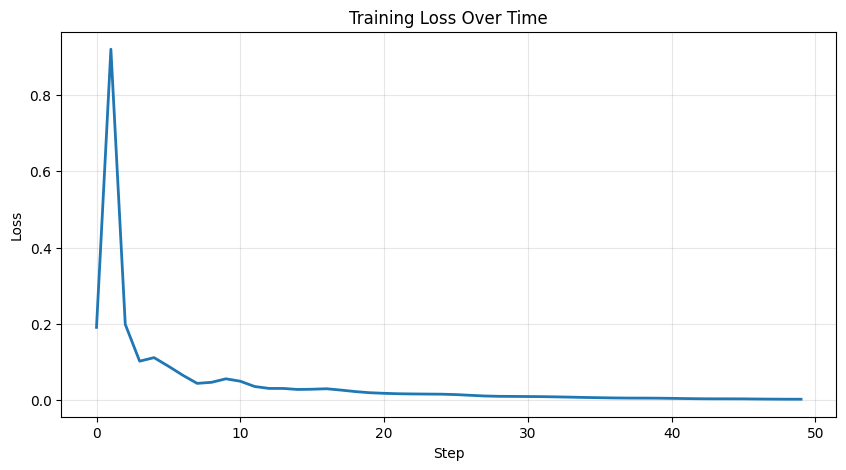

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()